# Reviewer Response Figures:


#### Setup

In [1]:
from pathlib import Path
import os
import notebook_setup
info = notebook_setup.setup()
# Environment & Imports Setup
import matplotlib as matplotlib
%matplotlib inline 

#code ocean step
use_code_ocean = False
if use_code_ocean:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
import pandas as pd
import random
from datetime import datetime
from itertools import product

print(f"matplotlib {matplotlib.__version__} | Seaborn {sns.__version__}")
warnings.filterwarnings(action='ignore', category=FutureWarning)
pd.set_option('mode.use_inf_as_na', False) # pd.set_option('future.no_silent_downcasting', True)
np.random.seed(1) #set seed for reproducibility 
random.seed(1)
# Apply mplstyle via absolute path from setup info
style_path = Path(info["function_py_storage"]) / "paper_plot.mplstyle"
print(f"Loading style guide at {style_path}")
if style_path.is_file():
    plt.style.use(str(style_path))
else:
    print(f"[warn] Style not found at: {style_path}")
here = info["repo_root"]
print(f" Here: {here}")
_plot_posthoc_src = os.path.join(here, 'plot_posthoc_test', 'src')
if os.path.isdir(_plot_posthoc_src) and _plot_posthoc_src not in sys.path:
    sys.path.append(_plot_posthoc_src)
# Fix for seaborn 0.12.1 + pandas 2.0 compatibility
try:
    pd.get_option('mode.use_inf_as_null')
except (pd.errors.OptionError, KeyError):
    pd._config.config._global_config['mode']['use_inf_as_null'] = False
    pd._config.config._registered_options['mode.use_inf_as_null'] = pd._config.config.RegisteredOption(
        key='mode.use_inf_as_null',
        defval=False,
        doc="Deprecated",
        validator=lambda x: None,
        cb=None,
    )

#custom function import
import custom_module_imports as cmi 
from preprocess_data import hyper_param_dict, get_numeric_cols_timeseries, get_unit_mean_timeseries_by_phase, add_enriched_in_curr_phase_col, get_subject_stage_info_df
from helper_functions import save_fig_in_main_fig_dir,  save_plot_record_as_csv_txt, make_folder, plot_heatmap_w_kwargs, annotate_csv
from ax_modifier_functions import add_spaces_linebreak_to_stage_ticks, set_ax_title_xlabel_ylabel, set_pointplot_edgecolor, set_labels, set_stage_xticks_2_layer
from sns_plotting_config import * #import dicts containing default plot params
from plot_posthoc_test.plot_stat_annotate import *
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
##Set/create save and load folder paths 
results_location = Path(here).parents[0] / "results"
data_location = Path(here).parents[0] / "data"
make_folder(results_location)
make_folder(data_location)
print(f"Saving results in {results_location}. Data location is {data_location}")
csv_folder_most_recent = results_location/ f"analysis_CSV_output/" #folders that analysis output goes to
make_folder(csv_folder_most_recent)

matplotlib 3.8.4 | Seaborn 0.12.1
Loading style guide at c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code\Function .py Storage\paper_plot.mplstyle
 Here: c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\code
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results' already exists.
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data' already exists.
Saving results in c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results. Data location is c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data
The folder 'c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output' already exists.


<Figure size 960x720 with 0 Axes>

## Non-supplement

#### Autoencoder hidden layer/activation function comparison

In [2]:
sweep_df_filename = r"_content_NN_param_sweep_02_Feb_2026_annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet"
sweep_results_df = pd.read_parquet(data_location / Path(sweep_df_filename))

In [3]:
sweep_results_df

,db_index,final_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison,n_frames_to_draw,n_epochs,n_bootstrap,BATCH_SIZE,axis
0,1.426356,0.068241,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
1,1.482833,0.069200,relu,2,1,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
2,1.025204,0.070144,relu,2,2,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
3,0.784805,0.064127,relu,2,3,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
4,1.260454,0.066928,relu,2,4,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,2.643163,0.044813,mish,5,995,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23996,1.730298,0.042891,mish,5,996,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23997,1.963058,0.042783,mish,5,997,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0
23998,2.409398,0.042226,mish,5,998,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,500,50,1000,500,0


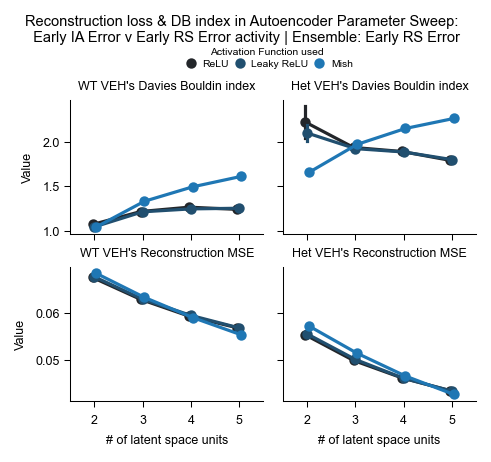

In [4]:
# Faceted pointplot: one panel per genotype
# set var names
comparison = sweep_results_df['comparison'].iloc[0]
ensemble = sweep_results_df['ensemble'].iloc[0]
# make plot
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['db_index', 'final_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'db_index': 'Davies Bouldin index', 'final_loss': 'Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s {row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 0.99, 
                  fontsize=7)
plt.savefig(f"sweep_results_{ensemble}.png", dpi=150, bbox_inches='tight')

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


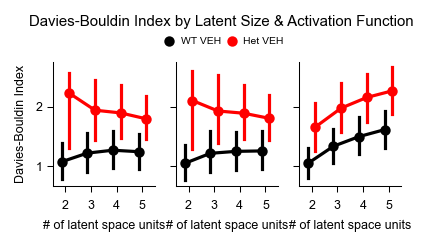

In [5]:
# FacetGrid: DB index by # latent units, faceted by activation function, dodged by genotype
geno_palette = {g: c for g, c in zip(geno_color_dict['hue_order'], geno_color_dict['palette'])}
db_df = sweep_results_df[sweep_results_df['geno'].isin(['WT VEH', 'Het VEH'])].copy()
db_df['geno'] = pd.Categorical(db_df['geno'], categories=['WT VEH', 'Het VEH'], ordered=True)

label_rename_act = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
db_df['activation_label'] = db_df['activation'].map(label_rename_act)

col_order = [label_rename_act[a] for a in ['relu', 'leaky_relu', 'mish']]
hue_order = ['WT VEH', 'Het VEH']

fig, axes = plt.subplots(1, len(col_order), figsize=(3, 1.2),
                         sharey=True, sharex=True)

for ax, act_label in zip(axes, col_order):
    subset = db_df[db_df['activation_label'] == act_label]
    sns.pointplot(data=subset, x='hidden_size', y='db_index', hue='geno', palette=geno_palette, hue_order=hue_order,
                  dodge=0.3, errorbar= ('pi', 75), ax=ax)
    set_ax_title_xlabel_ylabel(ax, label_dict = dict(xlabel="# of latent space units", ylabel="Davies-Bouldin Index" if ax == axes[0] else ""))

    # ax.set_title(act_label)
    # ax.set_xlabel("# of latent space units")
    # ax.set_ylabel("Davies-Bouldin Index" if ax == axes[0] else "")
    ax.get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.975), ncol=2, frameon=False)
fig.suptitle("Davies-Bouldin Index by Latent Size & Activation Function", y=1.06)
fig.subplots_adjust(top=0.8)

save_fig_in_main_fig_dir(fig, fig_name="Davies-Bouldin Index by Latent Size_Activation Function",
                         folder_key='r_1', filetypes_to_save=['png', 'svg'])

## Decoding # cells dropped:

#### create df with # of cells dropped by using union of activations for concat matrices

## Compare DFF vs Spikes ensemble values

#### import dff & spike datasets

In [6]:
#set what dataset to use, therefore waht col names are improtant 
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else:   
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
stage_col = 'task_phase_vec'


In [7]:
#load spike data:


trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ")
# get trial summary info
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()

#get processed dataset 
unit_mean_tseries =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)
print(n_total_units)

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64


In [8]:
enriched_spikes = unit_mean_tseries.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_spikes

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-104 Het VEH                      0             0.0   
             10_3_HET_RS1-107 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-104 Het VEH                      0               1   
             10_3_HET_RS1-107 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-104 Het VEH             1        0  
             10_3_HET_RS1-107 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[4776 rows x 6 columns]

In [9]:
# load DFF data
dff_file = data_location / Path(r"matlab_import_1000_shuff_minmax_normed_trial_tseries_26-Feb-2026\dff_matlab-made_trial_timeseries_normalized_2026-02-26 21.parquet")
trial_tseries_df_norm_dff = pd.read_parquet(dff_file)
n_total_units_dff = trial_tseries_df_norm_dff.groupby(by = 'geno_day')[unit_ID_col].nunique()
#make dff mean timeseries
unit_mean_tseries_dff =  get_unit_mean_timeseries_by_phase(trial_tseries_df_norm_dff,['trial_num'], [subject_col, unit_ID_col,'geno_day', stage_col], numeric_col)

print(n_total_units_dff)


geno_day
Het CLNZ        1094
Het VEH         1094
Het postCLNZ    1177
WT CLNZ         1246
WT VEH          1350
Name: neuron_ID, dtype: int64


In [10]:
enriched_dff = unit_mean_tseries_dff.groupby(by = ['subject_name', unit_ID_col, 'geno_day'])[stage_names].first()
enriched_dff

Early_IA_Correct  Early_IA_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0             1.0   
             10_3_HET_RS1-10  Het VEH                      0             1.0   
             10_3_HET_RS1-100 Het VEH                      0             0.0   
             10_3_HET_RS1-101 Het VEH                      0             0.0   
             10_3_HET_RS1-102 Het VEH                      0             0.0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-96   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-97   Het postCLNZ                 0             1.0   
             9_3_HET_RS3-98   Het postCLNZ                 0             0.0   
             9_3_HET_RS3-99   Het postCLNZ                 0             0.0   

                                            Early_RS_Correct  Early_RS_Error  \
subject_name neuron_ID        geno_day                                         
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH                      0               0   
             10_3_HET_RS1-10  Het VEH                      0               1   
             10_3_HET_RS1-100 Het VEH                      0               0   
             10_3_HET_RS1-101 Het VEH                      0               0   
             10_3_HET_RS1-102 Het VEH                      0               0   
...                                                      ...             ...   
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ                 0               0   
             9_3_HET_RS3-96   Het postCLNZ                 0               0   
             9_3_HET_RS3-97   Het postCLNZ                 0               0   
             9_3_HET_RS3-98   Het postCLNZ                 0               0   
             9_3_HET_RS3-99   Het postCLNZ                 0               0   

                                            Late_IA  Late_RS  
subject_name neuron_ID        geno_day                        
10_3_HET_RS1 10_3_HET_RS1-1   Het VEH             0        0  
             10_3_HET_RS1-10  Het VEH             0        0  
             10_3_HET_RS1-100 Het VEH             0        0  
             10_3_HET_RS1-101 Het VEH             0        0  
             10_3_HET_RS1-102 Het VEH             0        0  
...                                             ...      ...  
9_3_HET_RS3  9_3_HET_RS3-95   Het postCLNZ        0        0  
             9_3_HET_RS3-96   Het postCLNZ        0        0  
             9_3_HET_RS3-97   Het postCLNZ        0        0  
             9_3_HET_RS3-98   Het postCLNZ        0        0  
             9_3_HET_RS3-99   Het postCLNZ        0        0  

[5961 rows x 6 columns]

#### Reviewer figure: Heatmap of dff

In [11]:
##Define functions to use for activity matrix creation
def get_df_unit_mean_activity_matrix(unit_mean_tseries, 
                                     stage_names,
                                     numeric_col, 
                                     subj_name_col:str = 'subject_name', 
                                     ignore_pre:bool = True):
    all_geno_matrix,  all_geno_IDs= get_unit_mean_phase_activity_matrix( unit_mean_tseries, 
                                                                        use_enrich_unit_only=  False,
                                                                          stage_names =  stage_names,
                                                                          numeric_col =  numeric_col,
                                                                           subj_name_col = subj_name_col,
                                                                            unit_ID_col = unit_ID_col,
                                                                             ignore_pre= ignore_pre)
    mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(
        unit_mean_tseries.groupby(unit_ID_col)['geno_day'].first().to_frame(),left_index = True, right_index = True)
    if np.nanmean(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) == 0)>0:
        mean_AV_matrix = mean_AV_matrix.loc[(mean_AV_matrix.loc[:, stage_names].sum(axis = 1) > 0),:]
    return mean_AV_matrix

## preprocessing and normalization steps
def get_unit_mean_phase_activity_matrix(unit_mean_tseries, 
                                        use_enrich_unit_only,
                                          stage_names,
                                            numeric_col,
                                            subj_name_col = 'subject_name',
                                             unit_ID_col = 'neuron_ID',
                                              ignore_pre:bool= True, ):
    '''#TO- create matrix that's = concatenated vectors of all neuron mean activationni phase (output matrix = # units x # phases)    OUTPUT- '''
    matrix_IDs, stack_matrix,nan_df_list = dict(), dict(),[]
    skip_rec = dict()
    ## if going to skip pre-outcome period, change what counts as numeric col
    if ignore_pre:
        numeric_col = [col for col in numeric_col if '-' not in col]
    for dataset in unit_mean_tseries[subj_name_col].unique():
        matrix_list = []
        dataset_df = unit_mean_tseries.loc[ (unit_mean_tseries[subj_name_col] == dataset),:]
        if len(dataset_df.task_phase_vec.unique()) < len(stage_names):#check that dataset has ALL 6 phases, if not, skip
            skip_rec[dataset] = len(dataset_df.task_phase_vec.unique())
            # continue
        for stage in stage_names:
            phase_mask = (dataset_df.task_phase_vec == stage)
            matrix = dataset_df.loc[phase_mask, numeric_col].values #get phase entries, producing (dataset_neuron) x (time_bin matrix)
            #check if phase is present, if matrix extracted w phase trials is empty, assume mous elacks it
            if matrix.shape[0] == 0:
                matrix = np.tile(np.nan, (len(dataset_df[unit_ID_col].unique()), len(numeric_col)))
            if np.sum(np.isnan(matrix))>0:
                nan_df_list.append( dataset_df.loc[phase_mask, numeric_col])
            matrix_list.append(matrix)
        stack_matrix[dataset] = np.dstack(matrix_list)
        matrix_IDs[dataset] = dataset_df.loc[phase_mask, unit_ID_col].values
    all_geno_matrix = np.concatenate([val for val in stack_matrix.values()], axis = 0)
    all_geno_IDs =  np.concatenate([val for val in matrix_IDs .values()], axis = 0)
    return all_geno_matrix, all_geno_IDs

## extract tseries of interest to create AV matrix
ID_col_to_drop = 'cell' 
AV_matrix = get_df_unit_mean_activity_matrix(unit_mean_tseries_dff, stage_names, numeric_col,subj_name_col = 'subject_name', ignore_pre =True) # other way will not work: # AV_matrix =  get_df_unit_mean_activity_matrix(trial_tseries_df, stage_names, numeric_col)
AV_matrix['max_phase'] =AV_matrix[stage_names].idxmax(axis = 'columns')
max_95th_quantile = round(AV_matrix[stage_names].quantile(q = 0.95).max(),2)
min_5th_quantile = round(AV_matrix[stage_names].quantile(q = 0.05).min(),2)
print(f"5th percentile mean activation: {min_5th_quantile}, 95th percentile: {max_95th_quantile}")
WT_mask = AV_matrix.geno_day == "WT VEH"
AV_matrix['max_phase_val'] =AV_matrix.apply(lambda x: x[x.max_phase], axis = 1)
no_Early_IA_Error = AV_matrix.Early_IA_Error.isna()
has_Early_IA_Error = ~no_Early_IA_Error
AV_matrix.tail()

5th percentile mean activation: -0.44, 95th percentile: 1.77


C:\Users\13car\AppData\Local\Temp\ipykernel_144580\84984833.py:14: RuntimeWarning: Mean of empty slice
  mean_AV_matrix = pd.DataFrame(data =np.nanmean(all_geno_matrix, axis = 1), columns = stage_names, index = all_geno_IDs).merge(


,Early_IA_Correct,Early_IA_Error,Early_RS_Correct,Early_RS_Error,Late_IA,Late_RS,geno_day,max_phase,max_phase_val
9_3_HET_RS3-95,-0.333195,0.087563,-0.146866,-0.292228,0.049979,0.127020,Het postCLNZ,Late_RS,0.127020
9_3_HET_RS3-96,-0.272123,0.898245,0.664034,-0.285116,-0.272407,-0.231106,Het postCLNZ,Early_IA_Error,0.898245
9_3_HET_RS3-97,0.413765,3.780134,-0.268930,0.037388,-0.067772,0.014236,Het postCLNZ,Early_IA_Error,3.780134
9_3_HET_RS3-98,-0.143967,-0.113177,-0.181281,-0.214394,-0.199272,-0.196949,Het postCLNZ,Early_IA_Error,-0.113177
9_3_HET_RS3-99,-0.276386,-0.363606,-0.264345,0.040973,0.009452,-0.179825,Het postCLNZ,Early_RS_Error,0.040973


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


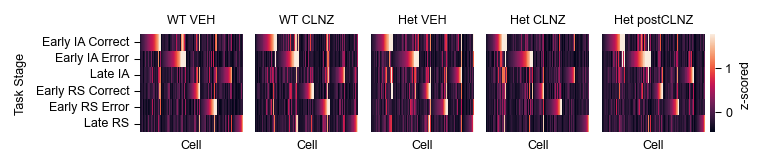

In [12]:
#plot unit heatmap for ALL GENOS
fig_mean_activity, axes = plt.subplots(1,5,figsize = (5,1), layout = 'constrained')
activity_type =  f"z-scored "
heatmap_clabel = activity_type

for count, geno in enumerate(geno_order_w_WT_CLNZ):
    plot_mask = (AV_matrix.geno_day == geno) & has_Early_IA_Error
    plot_data = AV_matrix.sort_values(by = ['max_phase','max_phase_val'],ascending = True).loc[plot_mask, stage_chrono_order].T
    plot_heatmap_w_kwargs(data =plot_data.rename(index = {p:p.replace('_', ' ') for p in plot_data.index}), ax =axes.flat[count],
                          kwarg_dict = {
                              'vmin': min_5th_quantile, 'vmax':max_95th_quantile, 'cbar_kws': {'label': heatmap_clabel},
                              'cbar': {True: True, False: False}[count == len(geno_order_w_WT_CLNZ)-1], 'yticklabels': True, 'xticklabels':False},
                          label_dict = {'xlabel': f"Cell", 'ylabel': {False:"Task Stage", True: None}[count > 0], 'title': geno})#plot heatmap
    axes.flat[count].set_yticks({True:[], False: axes.flat[count].get_yticks()}[count > 0])
#save figs
fig_prefix = "supp_" #for sorting in folder
fig_name = 'one_row_cell stage-activity sorted heatmap'
fig_mean_activity.get_axes()
save_fig_in_main_fig_dir(fig_mean_activity, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['png'])

#### Reviewer figure- compute ensemble size/distribution

In [13]:
#calculate distribution of enrichment in dff data
unique_ID_enrichment_dff = unit_mean_tseries_dff.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich_dff = unique_ID_enrichment_dff.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = 'prop_enriched')
prop_of_cells_enrich_n_stages_dff = unique_ID_enrichment_dff.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=True).rename('prop_enrich').reset_index()
prop_of_cells_enrich_n_stages_dff.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.690128
1,Het CLNZ,1.0,0.192870
2,Het CLNZ,2.0,0.065814
3,Het CLNZ,3.0,0.035649
4,Het CLNZ,4.0,0.011883


In [14]:
import helper_functions
print(dir(helper_functions))

['DEFAULT_DATE_FORMAT', 'Path', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'add_bin_end_col', 'add_dict_field_to_dicts', 'add_spaces_linebreak_to_stage_ticks', 'add_unique_ID_col_to_trial_series_df', 'annotate_csv', 'axmod', 'bin_post_outcome', 'cdist', 'check_if_row_has_nan', 'datetime', 'dfanno', 'drop_partial_bin', 'fig_nums', 'fig_save_dir', 'find_n_bins_pre_post_get_new_bin_mapper', 'flatten_2_row_mosaic', 'full_annotate_2_phase_table', 'get_ID_enriched_units_by_phase', 'get_PCA_obj_and_transform_matrix', 'get_PCA_scatter_kwarg_dict', 'get_ax_linedata_and_y_offset', 'get_best_fit_line', 'get_bin_end_str', 'get_bool_category_vecs', 'get_class_AVs', 'get_col_w_str', 'get_correct_error_str_list', 'get_cosine_sim', 'get_cosine_sim_of_class_AVs', 'get_datetag', 'get_df_unit_mean_activity_matrix', 'get_early_rule_str_list', 'get_frame_cols', 'get_frame_nonframe_cols_of_tseries', 'get_geno_comparisons_stratefied_by_phase', 'g

The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


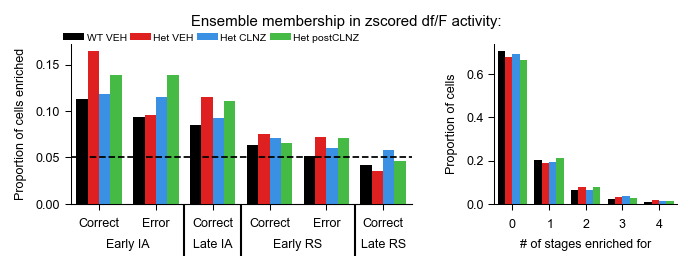

In [15]:
fig, axes = plt.subplots(1,2, figsize = (4.5,1.5), layout = 'constrained', width_ratios = [0.65, 0.35], gridspec_kw = dict(wspace = 0.1))

## plot distib of # enriched units by phase
ax_prop_enrich = axes[0]
g = sns.barplot(ax =ax_prop_enrich, data =geno_mean_enrich_dff, x = 'phase', y = 'prop_enriched',
                order = phase_list_IA_RS_chrono, **geno_color_dict)
ax_prop_enrich.axhline(y = 0.05, color = 'black', linestyle = '--')
sec, sec2, is_dict = set_stage_xticks_2_layer(ax_prop_enrich, phase_list_IA_RS_chrono) ## given ordering of xposition, get the list of what ticks are belonging to what task stage
set_ax_title_xlabel_ylabel(ax_prop_enrich, {'title': None,'ylim': [0, None], 'legend_false':True, 'ylabel':  f"Proportion of cells enriched", 'xlabel': None})#f"Task Stage"}) #f' Prop. of cells active > shuffle 95%ile'

##plot the distribution of values
ax_barplot = axes[1]
sns.barplot(ax = ax_barplot, data= prop_of_cells_enrich_n_stages_dff, x = 'num_enrich',  y = 'prop_enrich',  **geno_color_dict_no_errorbar) ## tune params
set_ax_title_xlabel_ylabel(ax_barplot, label_dict = {'title': None, 'xlim': [-0.5, 4.5], 'ylabel': f"Proportion of cells", 'legend_false':True,'xlabel': "# of stages enriched for"})
ax_barplot.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))

#set figure legends and info 
hand, labs = ax_barplot.get_legend_handles_labels() #pull legend from final PCA object and delete it
fig.legend(hand, labs, bbox_to_anchor=(0.3, 0.95),loc = 'lower center', ncols =4, frameon = False, title =None, **legend_defaults)
fig.suptitle(f"Ensemble membership in zscored df/F activity:", y = 1.1)
#####save fig
fig_name =  r"SUPP_ dff # enriched stage & % enriched by stage_ barplot"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

#### Compare ensemble distributions in dff and raster: 

In [16]:
#calculate distribution of enrichment in dff data
unique_ID_enrichment = unit_mean_tseries.groupby(by = ['geno_day', unit_ID_col])[stage_names].first()
# bin_ends = get_numeric_col_bin_end_float(numeric_col)
geno_mean_enrich = unique_ID_enrichment.groupby('geno_day').agg({ **{p: 'mean' for p in stage_names}}).reset_index().melt(id_vars = 'geno_day', var_name = 'phase', value_name = r'prop_enriched')
prop_of_cells_enrich_n_stages = unique_ID_enrichment.sum(axis=1).rename('num_enrich').groupby('geno_day').value_counts(normalize=True).rename('prop_enrich').reset_index()
prop_of_cells_enrich_n_stages.head()

,geno_day,num_enrich,prop_enrich
0,Het CLNZ,0.0,0.632794
1,Het CLNZ,1.0,0.247113
2,Het CLNZ,2.0,0.079677
3,Het CLNZ,3.0,0.027714
4,Het CLNZ,4.0,0.009238


In [17]:
geno_mean_enrich.head()

,geno_day,phase,prop_enriched
0,Het CLNZ,Early_IA_Correct,0.125866
1,Het VEH,Early_IA_Correct,0.165904
2,Het postCLNZ,Early_IA_Correct,0.150480
3,WT CLNZ,Early_IA_Correct,0.117763
4,WT VEH,Early_IA_Correct,0.100926


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


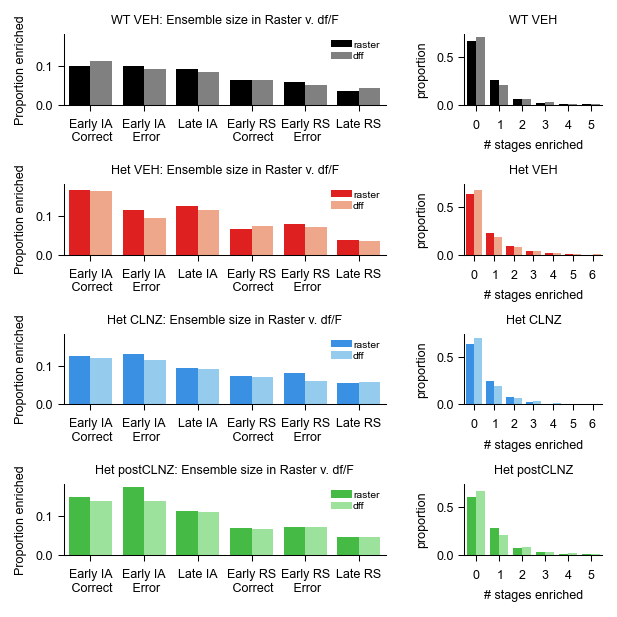

In [18]:
# combine raster & dff dataframes with a datatype label
combined_enrich = pd.concat([
    geno_mean_enrich.assign(datatype='raster'),
    geno_mean_enrich_dff.assign(datatype='dff')
])
combined_pdf = pd.concat([
    prop_of_cells_enrich_n_stages.assign(datatype='raster'),
    prop_of_cells_enrich_n_stages_dff.assign(datatype='dff')
])

# light named-color variant for each geno color
light_color_list = ['grey', 'lightsalmon', 'lightskyblue', 'lightgreen']

fig, axes = plt.subplots(len(geno_order), 2, 
                         figsize=(4, 4),
                         layout='constrained', sharey='col',
                           width_ratios = [0.7, 0.3], gridspec_kw = dict(wspace = 0.1) )

for row, geno in enumerate(geno_order):
    palette = {'raster': color_list[row], 'dff': light_color_list[row]}

    # --- Col 0: % enriched per stage ---
    ax = axes[row, 0]
    sns.barplot(ax=ax, data=combined_enrich[combined_enrich.geno_day == geno],
                x='phase', y='prop_enriched', hue='datatype', hue_order=['raster', 'dff'],
                order=phase_list_IA_RS_chrono, palette=palette, errorbar=None)
    #ad modification    
    set_ax_title_xlabel_ylabel(ax, {'title': f"{geno}: Ensemble size in Raster v. df/F", 'ylabel': 'Proportion enriched', 'xlabel': None})
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    ax.legend(ncol = 1, frameon= False)
    
    # --- Col 1: PDF of # stages enriched ---
    ax = axes[row, 1]
    sns.barplot(ax=ax, data=combined_pdf[combined_pdf.geno_day == geno],
                x='num_enrich', y='prop_enrich', hue='datatype', hue_order=['raster', 'dff'],
                palette=palette, errorbar=None)
    set_ax_title_xlabel_ylabel(ax, {'title': geno, 'xlabel': '# stages enriched',
                                    'ylabel': 'proportion'})
    ax.get_legend().remove()
    ax.xaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter(useMathText=True))

## save fig
fig_name = "Revision_SUPP_ dff_v_spike_ensemble_size"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)

####  Ensemble % conserved 

In [19]:
merged_enriched_chunks = pd.merge(enriched_spikes,enriched_dff, how = 'inner', on=['subject_name', 'geno_day', unit_ID_col], suffixes=('_dff', '_spikes'))
merged_enriched_chunks.sample()

,,,Early_IA_Correct_dff,Early_IA_Error_dff,Early_RS_Correct_dff,Early_RS_Error_dff,Late_IA_dff,Late_RS_dff,Early_IA_Correct_spikes,Early_IA_Error_spikes,Early_RS_Correct_spikes,Early_RS_Error_spikes,Late_IA_spikes,Late_RS_spikes
subject_name,geno_day,neuron_ID,,,,,,,,,,,,
13_8_HET_RS2,Het CLNZ,13_8_HET_RS2-62,0,0.0,0,0,0,0,0,0.0,0,0,0,0


In [20]:
# Cross-tabulation of dff vs spikes enrichment, faceted by geno_day
dff_cols = [c for c in merged_enriched_chunks.columns if c.endswith('_dff')]
base_stages = [c.replace('_dff', '') for c in dff_cols]

summary_rows = []
for stage in base_stages:
    dff_col = f"{stage}_dff"
    spike_col = f"{stage}_spikes"
    pair = merged_enriched_chunks[[dff_col, spike_col]].dropna()
    pair = pair.assign(**{dff_col: pair[dff_col].astype(int), spike_col: pair[spike_col].astype(int)})

    for geno_day, grp in pair.groupby(level='geno_day'):
        n = len(grp)
        both_0    = ((grp[dff_col] == 0) & (grp[spike_col] == 0)).sum()
        dff_only  = ((grp[dff_col] == 1) & (grp[spike_col] == 0)).sum()
        spike_only = ((grp[dff_col] == 0) & (grp[spike_col] == 1)).sum()
        both_1    = ((grp[dff_col] == 1) & (grp[spike_col] == 1)).sum()
        summary_rows.append({
            'stage': stage,
            'geno_day': geno_day,
            'n': n,
            'neither': both_0,
            'dff_only': dff_only,
            'spikes_only': spike_only,
            'both': both_1,
        })

crosstab_summary = pd.DataFrame(summary_rows)
# Add percentage columns
for col in ['neither', 'dff_only', 'spikes_only', 'both']:
    crosstab_summary[f'{col}_pct'] = (crosstab_summary[col] / crosstab_summary['n'] * 100).round(1)

display(crosstab_summary)


,stage,geno_day,n,neither,dff_only,spikes_only,both,neither_pct,dff_only_pct,spikes_only_pct,both_pct
0,Early_IA_Correct,Het CLNZ,866,711,27,46,82,82.1,3.1,5.3,9.5
1,Early_IA_Correct,Het VEH,874,673,28,56,117,77.0,3.2,6.4,13.4
2,Early_IA_Correct,Het postCLNZ,937,737,39,59,102,78.7,4.2,6.3,10.9
3,Early_IA_Correct,WT CLNZ,1019,848,30,51,90,83.2,2.9,5.0,8.8
4,Early_IA_Correct,WT VEH,1080,898,38,73,71,83.1,3.5,6.8,6.6
5,Early_IA_Error,Het CLNZ,742,608,28,37,69,81.9,3.8,5.0,9.3
6,Early_IA_Error,Het VEH,749,636,24,26,63,84.9,3.2,3.5,8.4
7,Early_IA_Error,Het postCLNZ,689,540,31,29,89,78.4,4.5,4.2,12.9
8,Early_IA_Error,WT CLNZ,838,720,23,35,60,85.9,2.7,4.2,7.2
9,Early_IA_Error,WT VEH,870,751,25,33,61,86.3,2.9,3.8,7.0


#### Get cell overlap

## Rand_permute vs circle ens. size, with FDR

In [21]:
#return_FDR_pvalue_df() is called on DF, which sorts values, find crit value, then check pvalue against that critical value
## multiple corrections functions
def return_FDR_pvalue_df(pval_vec_test_input, pvalue_col_name, FDR_alpha_to_use = 0.05):
    """ perform 2step FDR on p-value vector """ 
    #to : given a vector othat inlclues the combined name + pvalue
    #specify what col this pvalue is within

    critical_value_at_sorted_index = return_critical_value_vector(FDR_alpha_to_use, len(pval_vec_test_input)) #vector where position k = k * alpha value / len of overall vector
    #important- keep ID of position to merge appropriately 
    if type(pval_vec_test_input) is pd.core.series.Series:
        pvals_sorted = pval_vec_test_input.sort_values()
    else:
        pvals_sorted = pval_vec_test_input.sort_values(by = pvalue_col_name)
    pval_below_crit =  pvals_sorted[pvalue_col_name] <= critical_value_at_sorted_index #bool vec: true if pvalue <= crit value at equivalent index
    print(f"np.sum(pval_below_crit) = {np.sum(pval_below_crit)}")
    print(f"pval_below_crit {pval_below_crit}")
    # find max p val for 2 step
    if np.sum(pval_below_crit) > 0:
            max_p_below_crit_val = np.max(pvals_sorted[pval_below_crit]) #the larges p value that still is below critical value
    else:
            max_p_below_crit_val = pd.Series()
            max_p_below_crit_val[pvalue_col_name] = 0
    
    print(max_p_below_crit_val)
    # print(pvals_sorted[pval_below_crit])

    pval_vec_test_input['pval_below_crit'] =pval_below_crit
    pval_vec_test_input['crit_value'] =critical_value_at_sorted_index
    #given the maximum p value that is still below its corresponding crit value, threshold all pvalues
    pval_vec_test_input['is_pval_sig_fdr'] = pval_vec_test_input[pvalue_col_name] <= max_p_below_crit_val[pvalue_col_name]
    return pval_vec_test_input, pvals_sorted[pval_below_crit]

## minimum viable prod:  return correction col, no critical bvalue
def get_significance_multi_correction(pval_col, correction_type, alpha = 0.05, num_unique_comparisons= None):
    '''  
    inputs:    pval_col: numpy array: 
    '''
    #takes FDR or bonf
    if num_unique_comparisons == None: #set default to len of pval_col
        num_unique_comparisons= len(pval_col)
    #returns series of corrections
    if correction_type == "bonf":
        corrected_col =  pval_col<(alpha/num_unique_comparisons)
    if correction_type == "FDR": # create FDR significance vector
        corrected_col, crit_vals = return_fdr_correction_on_pval_vector(pval_col, alpha)
    return corrected_col

#code for FDR comparison on pvalue vector
# Calculate each individual p-value’s Benjamini-Hochberg critical value, using the formula (i/m)Q, where:
#    # i = the individual p-value’s rank,    # m = total number of tests,    # Q = the false discovery rate (a percentage, chosen by you).
def return_fdr_correction_on_pval_vector(input_pval_vec, alpha = 0.05):
    #inputs- input_pval_vec, numpy vecor 
    pvals_sorted = np.sort(input_pval_vec)
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_vec)) #vector where position k = k * alpha value / len of overall vector
    # for sorted position k, find k*alpha/length(vector) which = factor adjustment that will be MULTIPLIED pvalue
    pval_sig_fdr =  pvals_sorted <= critical_value_at_sorted_index

    # now find largest P(k) such that P(k) < critical value
    if np.sum(pval_sig_fdr) > 0:
        max_p_below_crit_val = np.max(pvals_sorted[pval_sig_fdr]) #the larges p value that still is below critical value
    else:
        max_p_below_crit_val = 0
    #this uses original pvale vec, then thresholds
    is_pval_sig_fdr = input_pval_vec <= max_p_below_crit_val # B-H finds largest K such that P <= K
    #all p values below max_p_below_crit_val is significant
    return is_pval_sig_fdr, critical_value_at_sorted_index

#return the critical value
def return_critical_value_vector(input_alpha, vec_len):
        critical_value_at_sorted_index = input_alpha* (np.arange(1,vec_len+1)/vec_len) #vector where position k = k * alpha value / len of overall vector
        return critical_value_at_sorted_index

# #because I want to keep the crit value associated with the p-value, rather than just the sorted crit value, I input as a series
# input_pval_series = test_df[pval_col_name].copy()
# alpha = 0.05
## functio mockup
def perform_BH_FDR_on_pvalue_series(input_pval_series: pd.Series, 
                                    pval_col_name:str =  "percent_shuffle >= real",
                                    alpha:float = 0.05):
    """ Funciton to take pd.Series with p-values, perform 2-step BH FDR and return corrected significance and associ. crit values used
    returns:
    merged_df: pandas df merging original input series with new FDR info"""
    input_pval_series= input_pval_series.to_frame() #change series to frame to allow adding
    sorted_input_pval_df = input_pval_series.sort_values(by = pval_col_name)
    #get critical value vector
    critical_value_at_sorted_index = return_critical_value_vector(alpha, len(input_pval_series)) #vector where position k = k * alpha value / len of overall vector
    print(f"Finding K for up to {len(input_pval_series)} places, with alpha = {alpha}")
    # add critical value to sorted df
    sorted_input_pval_df['critical_val_at_sort_idx'] = critical_value_at_sorted_index
    sorted_input_pval_df['is_sorted_pval_below_crit_val']=  sorted_input_pval_df.apply(lambda x: x[pval_col_name] <= x['critical_val_at_sort_idx'], axis = 1)

    #if at least 1 p-value is < k, find the following:
    if sorted_input_pval_df['is_sorted_pval_below_crit_val'].sum() > 0:
    
    #find maximum p-value that is less than or equal to K (critical value at its index)
        sorted_pval_below_k_bool =   sorted_input_pval_df['is_sorted_pval_below_crit_val']
        #use boolean to index into sorted array, and get largest p-value 
        max_pval_below_crit_val = sorted_input_pval_df.loc[sorted_pval_below_k_bool, pval_col_name].max()
        #threshold ALL pvalues with largest sub-K p-value:
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = sorted_input_pval_df[pval_col_name] <= max_pval_below_crit_val
    
    else: #else, fill in gaps and set all bool sig below FDr to 0
        print(f" FDR results in 0 p-vals < threshold")
        sorted_input_pval_df['is_pval_below_max_subK_pval'] = False
        max_pval_below_crit_val = np.nan
    print(f"max_pval_below_crit_val = {max_pval_below_crit_val}")

    #after everything, re-join on index with input series
    #add sort col
    sorted_input_pval_df['BH_rank_k'] = np.arange(1, len(sorted_input_pval_df) + 1) 
    function_added_cols = ['is_pval_below_max_subK_pval','is_sorted_pval_below_crit_val','critical_val_at_sort_idx','BH_rank_k']
    merged_df = input_pval_series.merge(sorted_input_pval_df[function_added_cols], left_index = True, right_index = True)
    #record max p value used
    merged_df['max_p_below_k']= max_pval_below_crit_val
    # check that you mantained size of series
    assert sorted_input_pval_df.shape[0] == input_pval_series.shape[0]
    return merged_df



#### Import label permuted data

In [22]:
rand_perm_type = 'random_permute'
#map metadata cols added in matlab, to unlabeled cols in csv import
unnamed_var_map = {'Var1_1': 'run_date',
'Var1_2': 'num_shuffles',
'Var1_3': 'threshold_percentile', 
'Var1_4': 'dropped_low_value_peaks',
'Var1_5': 'cutoff_filter',
'Var1_6': 'peak_event_cutoff_percentile',
'name': 'subject_name'}

# import file itself
random_permute_file = data_location / Path(r"matlab_10K_shuff_randperm_ensemble_data\WT_CLNZ_complexTACO- neurons_randperm_activity by task phase_01-Mar-2026.xls")
print(f"Loading randomly permuted shuffles from {random_permute_file} ")
rand_perm_df = pd.read_excel(random_permute_file).replace(-99, np.nan)
rand_perm_df = rand_perm_df.drop(columns = [x for x in rand_perm_df.columns if ('pre' in x) or ('ITI' in x)]) #drop unnamed cols
rand_perm_df = rand_perm_df.rename(columns = unnamed_var_map) #rename unnamed cols to metadata cols
rand_perm_df = rand_perm_df.rename(columns ={c: c.replace("_post_outcome_", "_") for c in rand_perm_df.columns if "post_outcome" in c}) #rename unnamed cols to metadata cols

rand_perm_df['neuron_ID'] = rand_perm_df['subject_name'].astype(str) + "-" + rand_perm_df['neuron_ID'].astype(str) #make unique ID col for merging
annotate_csv(rand_perm_df, 'subject_name')
rand_perm_df.sample()

Loading randomly permuted shuffles from c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\data\matlab_10K_shuff_randperm_ensemble_data\WT_CLNZ_complexTACO- neurons_randperm_activity by task phase_01-Mar-2026.xls 


,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,geno,neuron_ID,peak_dff_threshold_percentile,run_date,num_shuffles,threshold_percentile,dropped_low_value_peaks,cutoff_filter,peak_event_cutoff_percentile,day
1779,NaN,1,0,0,0,0,NaN,0.006,1.0,1.0,...,WT,13_6_WT_RS1-137,1,01-Mar-2026 20:49:41,1000,95,False,bimodality,1,1


#### Perform FDR on random permute shuffled data

In [23]:
id_cols = ['subject_name', 'geno_day', 'geno', 'day', 'neuron_ID','run_date', 'num_shuffles']
#wide_to_long finds stubnames, splits the rest of the col name by sep, and uses piece after stubname as value of new 'j' col
rand_perm_melted = pd.wide_to_long(rand_perm_df,
                                   i = id_cols, 
                                   stubnames = ['post_outcome', 'pvalue', 'threshold_95'], 
                                   suffix = ".+",
                                   sep = "_",
                                   j = 'task_stage')#drop unused metadata cols
rand_perm_melted = rand_perm_melted.drop(
    columns = ['baseline_sig_cells', 'peak_dff_threshold_percentile'] + [v for v in unnamed_var_map.values() if v in rand_perm_melted.columns]).reset_index()
rand_perm_melted

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667
...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889


In [24]:
test_df = rand_perm_melted
#set FDR params:
pval_col_name = "pvalue"
alpha_FDR = 0.05
#iterate using FDR by subject on task stage
all_fdr_pval = []
all_fdr_pval = []

for s in stage_names:
    for g in geno_order_w_WT_CLNZ:
        print(f"Performing FDR for stage {s} and geno {g}")
        stage_df = test_df.loc[(test_df.task_stage == s) & (test_df.geno_day == g),:]
        input_pval_series = stage_df[pval_col_name]
        print(f" {s} -  matrix shape - {input_pval_series.shape}")
        corr_pval = perform_BH_FDR_on_pvalue_series(input_pval_series, pval_col_name = pval_col_name, alpha = alpha_FDR)
        all_fdr_pval.append(corr_pval)

stage_FDR_df = test_df.merge(pd.concat(all_fdr_pval), left_index = True, right_index = True,suffixes = ("", "_fdr"))
stage_FDR_df

Performing FDR for stage Early_IA_Correct and geno WT VEH
 Early_IA_Correct -  matrix shape - (1350,)
Finding K for up to 1350 places, with alpha = 0.05
max_pval_below_crit_val = 0.014
Performing FDR for stage Early_IA_Correct and geno WT CLNZ
 Early_IA_Correct -  matrix shape - (1246,)
Finding K for up to 1246 places, with alpha = 0.05
max_pval_below_crit_val = 0.012
Performing FDR for stage Early_IA_Correct and geno Het VEH
 Early_IA_Correct -  matrix shape - (1094,)
Finding K for up to 1094 places, with alpha = 0.05
max_pval_below_crit_val = 0.016
Performing FDR for stage Early_IA_Correct and geno Het CLNZ
 Early_IA_Correct -  matrix shape - (1094,)
Finding K for up to 1094 places, with alpha = 0.05
max_pval_below_crit_val = 0.011
Performing FDR for stage Early_IA_Correct and geno Het postCLNZ
 Early_IA_Correct -  matrix shape - (1177,)
Finding K for up to 1177 places, with alpha = 0.05
max_pval_below_crit_val = 0.014
Performing FDR for stage Early_IA_Error and geno WT VEH
 Early_IA

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005


#### Merge circ shuff & label_permute

In [25]:
## import TACO file directly of 10K spike circ. shuffles
matlab_TACO_filename = data_location / Path(r"29-Jan-2026_neurons_ sig enrichment vectors by task stage_10000__shuffles_hour__15\WT_CLNZ_complexTACO- neurons_activity by task phase_30-Jan-2026.xls")
cell_period_active = pd.read_excel(matlab_TACO_filename, na_values=[-99, '-99']).replace(-99, np.nan)

## process/drop unneeded cols 
generic_col_to_drop = [c for c in cell_period_active.columns if any(p in c for p in ('peak', 'ITI', 'cutoff', 'pre_outcome'))]
print(f" dropping cols: {generic_col_to_drop}")
cell_period_active.drop(columns = generic_col_to_drop + ['Var1_4', 'Var1_5', 'Var1_6'], inplace = True)
cell_period_active = cell_period_active.rename(columns = {'name': 'subject_name', 'Var1_1': "Run_end_time", 'Var1_2': "num_shuffles", 'Var1_3':"percentile_cutoff"})
cell_period_active['session'] = cell_period_active['subject_name'].str.split("_").str.get(3)
cell_period_active= cell_period_active.rename(columns ={c: c.replace("_post_outcome_", "_") for c in cell_period_active.columns if "post_outcome" in c}) #rename unnamed cols to metadata cols
## add neuron Id unique col 
cell_col = 'neuron_ID'
cell_period_active['raw_ID'] = cell_period_active[cell_col].astype(str)
cell_period_active[cell_col] = cell_period_active['subject_name'] + '-' + cell_period_active['raw_ID']
annotate_csv(cell_period_active, 'subject_name')
print(cell_period_active.info())
cell_period_active.head()


 dropping cols: ['pre_outcome_Early_IA_Error', 'pre_outcome_Early_IA_Correct', 'pre_outcome_Late_IA', 'pre_outcome_Early_RS_Error', 'pre_outcome_Early_RS_Correct', 'pre_outcome_Late_RS', 'ITI_Early_IA_Error', 'ITI_Early_IA_Correct', 'ITI_Late_IA', 'ITI_Early_RS_Error', 'ITI_Early_RS_Correct', 'ITI_Late_RS', 'pvalue_pre_outcome_Early_IA_Error', 'pvalue_pre_outcome_Early_IA_Correct', 'pvalue_pre_outcome_Late_IA', 'pvalue_pre_outcome_Early_RS_Error', 'pvalue_pre_outcome_Early_RS_Correct', 'pvalue_pre_outcome_Late_RS', 'pvalue_ITI_Early_IA_Error', 'pvalue_ITI_Early_IA_Correct', 'pvalue_ITI_Late_IA', 'pvalue_ITI_Early_RS_Error', 'pvalue_ITI_Early_RS_Correct', 'pvalue_ITI_Late_RS', 'threshold_95_pre_outcome_Early_IA_Error', 'threshold_95_pre_outcome_Early_IA_Correct', 'threshold_95_pre_outcome_Late_IA', 'threshold_95_pre_outcome_Early_RS_Error', 'threshold_95_pre_outcome_Early_RS_Correct', 'threshold_95_pre_outcome_Late_RS', 'threshold_95_ITI_Early_IA_Error', 'threshold_95_ITI_Early_IA_Corre

,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,subject_name,geno_day,geno,neuron_ID,Run_end_time,num_shuffles,percentile_cutoff,session,raw_ID,day
0,1.0,0,0,0,0,0,0.0004,1.0000,1.0000,1.0000,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-1,30-Jan-2026 17:20:28,10000,95,RS1,1,1
1,0.0,0,0,0,0,0,1.0000,1.0000,1.0000,1.0000,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-2,30-Jan-2026 17:20:28,10000,95,RS1,2,1
2,1.0,0,0,0,0,0,0.0110,1.0000,0.1441,0.2461,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-3,30-Jan-2026 17:20:28,10000,95,RS1,3,1
3,0.0,0,0,1,0,0,1.0000,1.0000,0.1661,0.0406,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-4,30-Jan-2026 17:20:28,10000,95,RS1,4,1
4,0.0,0,0,0,0,0,1.0000,0.1009,0.4649,0.0815,...,10_3_HET_RS1,Het VEH,HET,10_3_HET_RS1-5,30-Jan-2026 17:20:28,10000,95,RS1,5,1


In [26]:
## import real data and use list of neuron IDs contained in df to filter out inactive TACO neurons:
trial_df_filename = data_location /  r"matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet" # new matlab made 10k shuffle file 
# trial_df_filename = data_location /  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm

,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,pvalue_post_outcome_Late_RS,Run_end_time,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
0,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-1,post_outcome,10_3_HET_RS1,RS1,1,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
2,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-3,post_outcome,10_3_HET_RS1,RS1,3,1,...,0.3656,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
3,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-4,post_outcome,10_3_HET_RS1,RS1,4,1,...,1.0000,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0000,False
4,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-5,post_outcome,10_3_HET_RS1,RS1,5,1,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.2900,True
5,Early_IA_Correct,IA,Correct,1,10_3_HET_RS1-6,post_outcome,10_3_HET_RS1,RS1,6,1,...,0.1980,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116370,Late_RS,RS,Correct,38,9_3_HET_RS3-209,post_outcome,9_3_HET_RS3,RS3,209,3,...,0.4277,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0150,True
116373,Late_RS,RS,Correct,38,9_3_HET_RS3-212,post_outcome,9_3_HET_RS3,RS3,212,3,...,0.4392,30-Jan-2026 17:20:28,10000,2.0,False,none,1.0,all_frames,0.0225,True
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,0.0483,30-Jan-2026 17:20:28,10000,1.0,True,none,1.0,all_frames,0.1500,True


In [27]:
cells_in_spike_df = trial_tseries_df_norm.neuron_ID.unique()
print(f"Number of unique neurons in spike timeseries df: {len(cells_in_spike_df)}")
## filter TACO df to only include neurons present in real data
filtered_cell_period_active = cell_period_active[cell_period_active[cell_col].isin(cells_in_spike_df)].copy()
print(f"Number of neurons in TACO df after filtering to those present in real data: {filtered_cell_period_active.shape[0]}")
filtered_cell_period_active.sample()

Number of unique neurons in spike timeseries df: 4776
Number of neurons in TACO df after filtering to those present in real data: 4776


,post_outcome_Early_IA_Error,post_outcome_Early_IA_Correct,post_outcome_Late_IA,post_outcome_Early_RS_Error,post_outcome_Early_RS_Correct,post_outcome_Late_RS,pvalue_Early_IA_Error,pvalue_Early_IA_Correct,pvalue_Late_IA,pvalue_Early_RS_Error,...,subject_name,geno_day,geno,neuron_ID,Run_end_time,num_shuffles,percentile_cutoff,session,raw_ID,day
3593,0.0,0,0,0,0,0,1.0,1.0,1.0,1.0,...,15_1_HET_RS3,Het postCLNZ,HET,15_1_HET_RS3-66,30-Jan-2026 17:20:28,10000,95,RS3,66,3


In [28]:
id_cols = ['subject_name', 'geno_day', unit_ID_col]
#wide_to_long finds stubnames, splits the rest of the col name by sep, and uses piece after stubname as value of new 'j' col
circ_shuf_melt = pd.wide_to_long(filtered_cell_period_active,
                                   i = id_cols, 
                                   stubnames = ['post_outcome', 'pvalue', 'threshold_95'], 
                                   suffix = ".+",
                                   sep = "_",
                                   j = 'task_stage')#drop unused metadata cols
circ_shuf_melt = circ_shuf_melt.drop(columns = ['baseline_sig_cells'] + [v for v in unnamed_var_map.values() if v in circ_shuf_melt.columns]).reset_index()
circ_shuf_melt

,subject_name,geno_day,neuron_ID,task_stage,Run_end_time,raw_ID,session,day,percentile_cutoff,geno,post_outcome,pvalue,threshold_95
0,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_IA_Error,30-Jan-2026 17:20:28,1,RS1,1,95,HET,1.0,0.0004,0.173333
1,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_IA_Correct,30-Jan-2026 17:20:28,1,RS1,1,95,HET,0.0,1.0000,0.096667
2,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Late_IA,30-Jan-2026 17:20:28,1,RS1,1,95,HET,0.0,1.0000,0.096000
3,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_RS_Error,30-Jan-2026 17:20:28,1,RS1,1,95,HET,0.0,1.0000,0.150833
4,10_3_HET_RS1,Het VEH,10_3_HET_RS1-1,Early_RS_Correct,30-Jan-2026 17:20:28,1,RS1,1,95,HET,0.0,1.0000,0.126667
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_IA_Correct,30-Jan-2026 17:20:28,215,RS3,3,95,HET,0.0,1.0000,0.029444
28652,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Late_IA,30-Jan-2026 17:20:28,215,RS3,3,95,HET,0.0,1.0000,0.023333
28653,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_RS_Error,30-Jan-2026 17:20:28,215,RS3,3,95,HET,0.0,1.0000,0.033333
28654,9_3_HET_RS3,Het postCLNZ,9_3_HET_RS3-215,Early_RS_Correct,30-Jan-2026 17:20:28,215,RS3,3,95,HET,0.0,1.0000,0.030000


In [29]:
stage_FDR_df

,subject_name,geno_day,geno,day,neuron_ID,run_date,num_shuffles,task_stage,post_outcome,pvalue,threshold_95,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k
0,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008
1,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016
2,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013
3,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011
4,10_3_HET_RS1,Het VEH,HET,1,10_3_HET_RS1-1,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35761,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014
35762,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009
35763,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009
35764,9_3_HET_RS3,Het postCLNZ,HET,3,9_3_HET_RS3-215,01-Mar-2026 20:49:41,1000,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005


In [30]:
from matplotlib_venn import venn2
use_custom_venn_colors = True
from ensemble_overlap import get_geno_stage_overlap_crosstab, plot_ensemble_venn, plot_save_ensemble_overlap_fig, compute_ensemble_overlap_chi2

## compute overlap statistics
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'],
                        ['Early_IA_Error', 'Early_RS_Error'], 
                        ['Early_IA_Correct', 'Late_IA'],
                         ['Late_IA','Early_RS_Correct']]
overlap_tab = compute_ensemble_overlap_chi2(unit_mean_tseries, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_tab.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


In [31]:
## set merge params
value_cols = ['post_outcome','pvalue','threshold_95']
id_cols = ['subject_name', unit_ID_col, 'geno_day', 'task_stage']
fdr_cols = ['pvalue_fdr', 'is_pval_below_max_subK_pval', 'is_sorted_pval_below_crit_val', 'critical_val_at_sort_idx', 'BH_rank_k', 'max_p_below_k']
## perform merge
ens_circ_vs_rand_perm = stage_FDR_df.loc[:, id_cols + value_cols + fdr_cols].merge(circ_shuf_melt.loc[:, id_cols + value_cols], on = id_cols, suffixes = ("_rand_perm", "_circ_shuff"))
ens_circ_vs_rand_perm =ens_circ_vs_rand_perm.rename(columns = {c: c.replace("post_outcome_", "enriched_") for c in ens_circ_vs_rand_perm.columns if "post_outcome" in c})


## possible change: add smoothed p-value (m + 1)/ (n + 1) to avoid 0 p-values, which cause issues with log scale plotting
# ens_circ_vs_rand_perm['smoothed_pvalue'] = (ens_circ_vs_rand_perm['pvalue'] + 1) / (ens_circ_vs_rand_perm['num_shuffles'] + 1)  
ens_circ_vs_rand_perm 

,subject_name,neuron_ID,geno_day,task_stage,enriched_rand_perm,pvalue_rand_perm,threshold_95_rand_perm,pvalue_fdr,is_pval_below_max_subK_pval,is_sorted_pval_below_crit_val,critical_val_at_sort_idx,BH_rank_k,max_p_below_k,enriched_circ_shuff,pvalue_circ_shuff,threshold_95_circ_shuff
0,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Error,1.0,0.0,0.031667,0.0,True,True,0.000046,1,0.008,1.0,0.0004,0.173333
1,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_IA_Correct,0.0,1.0,0.025833,1.0,False,False,0.024497,536,0.016,0.0,1.0000,0.096667
2,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Late_IA,0.0,1.0,0.024667,1.0,False,False,0.022943,502,0.013,0.0,1.0000,0.096000
3,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Error,0.0,1.0,0.028333,1.0,False,False,0.021298,466,0.011,0.0,1.0000,0.150833
4,10_3_HET_RS1,10_3_HET_RS1-1,Het VEH,Early_RS_Correct,0.0,1.0,0.026667,1.0,False,False,0.014671,321,0.007,0.0,1.0000,0.126667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28651,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_IA_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.014,0.0,1.0000,0.029444
28652,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Late_IA,0.0,1.0,0.007667,1.0,False,False,0.050000,1177,0.009,0.0,1.0000,0.023333
28653,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_RS_Error,0.0,1.0,0.010000,1.0,False,False,0.050000,1177,0.009,0.0,1.0000,0.033333
28654,9_3_HET_RS3,9_3_HET_RS3-215,Het postCLNZ,Early_RS_Correct,0.0,1.0,0.008889,1.0,False,False,0.050000,1177,0.005,0.0,1.0000,0.030000


#### Plot circ vs random shuffle of ensemble enrichment


In [32]:
#given a joined dataframe, plot as a barplot to compare 
# Reshape to long format for seaborn
plot_df = ens_circ_vs_rand_perm.melt(id_vars=['task_stage', 'subject_name', 'geno_day'],
                                    value_vars=['enriched_rand_perm', 'enriched_circ_shuff', 'is_pval_below_max_subK_pval'],
                                    var_name='correction',value_name='is_enriched')

plot_df['correction'] = plot_df['correction'].map({'enriched_rand_perm': 'Label-permute (p<0.05)',
                                                    'is_pval_below_max_subK_pval': 'Label-permute (FDR-corrected p <0.05)',
                                                    'enriched_circ_shuff': 'circle-shuffle (p<0.05)'})
plot_df


,task_stage,subject_name,geno_day,correction,is_enriched
0,Early_IA_Error,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),1.0
1,Early_IA_Correct,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
2,Late_IA,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
3,Early_RS_Error,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
4,Early_RS_Correct,10_3_HET_RS1,Het VEH,Label-permute (p<0.05),0.0
...,...,...,...,...,...
85963,Early_IA_Correct,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85964,Late_IA,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85965,Early_RS_Error,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0
85966,Early_RS_Correct,9_3_HET_RS3,Het postCLNZ,Label-permute (FDR-corrected p <0.05),0.0


In [33]:

# Per-subject percentages
subj_pct = plot_df.groupby(['task_stage', 'geno_day', 'subject_name', 'correction'])['is_enriched'].mean() * 100
subj_pct = subj_pct.reset_index(name='pct_enriched')
subj_pct


,task_stage,geno_day,subject_name,correction,pct_enriched
0,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,Label-permute (FDR-corrected p <0.05),44.354839
1,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,Label-permute (p<0.05),45.16129
2,Early_IA_Correct,Het CLNZ,10_3_HET_RS2,circle-shuffle (p<0.05),16.935484
3,Early_IA_Correct,Het CLNZ,13_3_HET_RS2,Label-permute (FDR-corrected p <0.05),27.358491
4,Early_IA_Correct,Het CLNZ,13_3_HET_RS2,Label-permute (p<0.05),28.301887
...,...,...,...,...,...
625,Late_RS,WT VEH,7_4_WT_RS1,Label-permute (p<0.05),17.5
626,Late_RS,WT VEH,7_4_WT_RS1,circle-shuffle (p<0.05),10.0
627,Late_RS,WT VEH,7_5_WT_RS1,Label-permute (FDR-corrected p <0.05),25.324675
628,Late_RS,WT VEH,7_5_WT_RS1,Label-permute (p<0.05),29.220779


The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


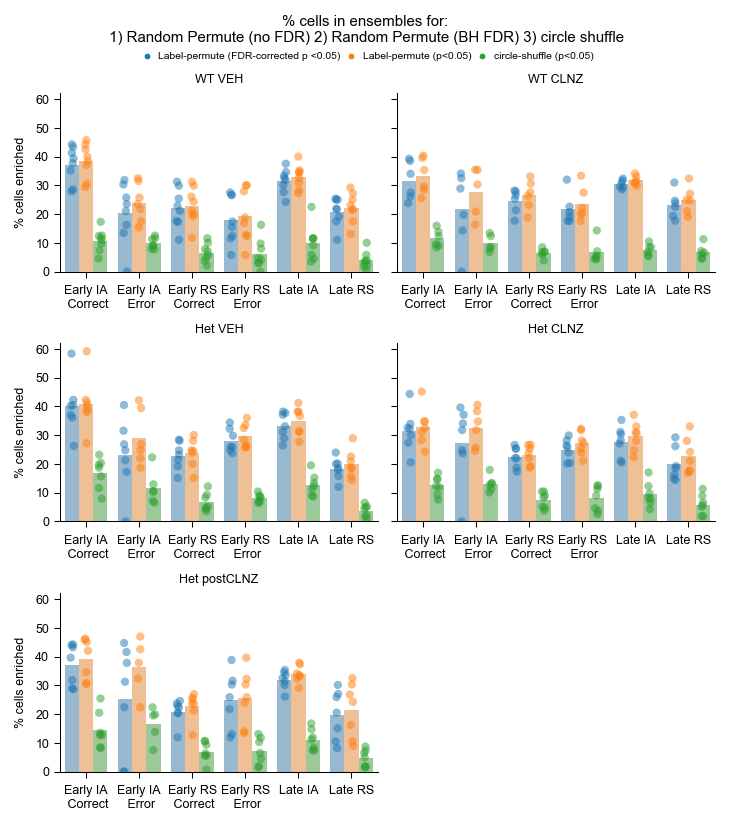

In [34]:

# Plot comparison
fig, axes = plt.subplots(3, 2, figsize=(4.75, 5), sharey = True, layout = 'constrained')
#3 facet by geno

y_val = 'pct_enriched'
x_val = 'task_stage'

#facet by geno_day
for g, geno in enumerate(geno_order_w_WT_CLNZ):
    ax = axes.flat[g]
    sns.stripplot(data=subj_pct[subj_pct['geno_day']==geno], x=x_val, y=y_val, hue='correction', ax=ax, dodge=True,  alpha=0.5, size=4, legend=g == 0)
    if g == 0:
        handles, labels = ax.get_legend_handles_labels() 

    sns.barplot(data=subj_pct[subj_pct['geno_day']==geno], x=x_val, y=y_val, hue='correction', ax=ax, alpha=0.5, errorbar=None)
    ax.get_legend().remove()
    #plot distribution of points w stripplot
    # set ax adjustment
    set_labels(ax, label_dict = {'xlabel': None, 'ylabel': r'% cells enriched', 'title': geno})
    ax.set_xticklabels(add_spaces_linebreak_to_stage_ticks(ax.get_xticklabels()))
    #if first element, move legend upwards
axes.flat[5].axis('off')

suptitle = f"% cells in ensembles for:\n 1) Random Permute (no FDR) 2) Random Permute (BH FDR) 3) circle shuffle"
fig.suptitle(suptitle, y = 1.07)
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),ncol=len(labels),title=None , frameon=False)

## save fig
fig_name = "Revision_SUPP_ dff_v_spike_ensemble_size_comparison_to_circ_shuff"
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['svg','png'],bbox_inches="tight",pad_inches=0)


## Compare Ensemble overlap- rand_perm vs circle 

#### Import overlap functions

In [35]:
from matplotlib_venn import venn2
use_custom_venn_colors = True
from ensemble_overlap import get_geno_stage_overlap_crosstab, plot_ensemble_venn, plot_save_ensemble_overlap_fig, compute_ensemble_overlap_chi2, make_premade_comparison_pvalue_df, update_posthoc_pvalues

## compute overlap statistics
all_ensemble_pairs =  [['Early_IA_Correct', 'Early_RS_Correct'],
                        ['Early_IA_Error', 'Early_RS_Error'], 
                        ['Early_IA_Correct', 'Late_IA'],
                         ['Late_IA','Early_RS_Correct']]
overlap_spikes = compute_ensemble_overlap_chi2(unit_mean_tseries, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_spikes.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,24,1080,0.022222,2.222222,75,46,"[[935, 75], [46, 24]]",53.541789,0.0,1,"[[917.4166666666666, 92.58333333333333], [63.5..."
1,WT CLNZ,Late_IA,Early_RS_Correct,11,1019,0.010795,1.079490,66,54,"[[888, 66], [54, 11]]",7.346526,0.006719,1,"[[881.9116781157998, 72.0883218842002], [60.08..."
2,Het VEH,Late_IA,Early_RS_Correct,26,874,0.029748,2.974828,84,32,"[[732, 84], [32, 26]]",55.601153,0.0,1,"[[713.2997711670481, 102.70022883295195], [50...."
3,Het CLNZ,Late_IA,Early_RS_Correct,20,866,0.023095,2.309469,62,43,"[[741, 62], [43, 20]]",36.581475,0.0,1,"[[726.9653579676674, 76.03464203233257], [57.0..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,27,937,0.028815,2.881537,78,38,"[[794, 78], [38, 27]]",61.349001,0.0,1,"[[774.2838847385273, 97.71611526147278], [57.7..."


In [36]:
## compute overlap stats for dff data
overlap_dff = compute_ensemble_overlap_chi2(unit_mean_tseries_dff, all_ensemble_pairs, geno_order_w_WT_CLNZ, stage_names)
overlap_dff.tail()

,geno_day,set_1_name,set_2_name,total_overlap,n_total,fraction_total_overlap,percent_total_overlap,n_only_in_set_1,n_only_in_set_2,contingency,statistic,pvalue,dof,expected_frequency
0,WT VEH,Late_IA,Early_RS_Correct,28,1350,0.020741,2.074074,87,57,"[[1178, 87], [57, 28]]",66.126294,0.0,1,"[[1157.2407407407406, 107.75925925925925], [77..."
1,WT CLNZ,Late_IA,Early_RS_Correct,18,1246,0.014446,1.444623,88,65,"[[1075, 88], [65, 18]]",18.071899,0.000021,1,"[[1064.0609951845906, 98.9390048154093], [75.9..."
2,Het VEH,Late_IA,Early_RS_Correct,41,1094,0.037477,3.747715,85,41,"[[927, 85], [41, 41]]",124.765923,0.0,1,"[[895.4442413162706, 116.55575868372944], [72...."
3,Het CLNZ,Late_IA,Early_RS_Correct,32,1094,0.029250,2.925046,69,46,"[[947, 69], [46, 32]]",97.26719,0.0,1,"[[922.2010968921389, 93.79890310786107], [70.7..."
4,Het postCLNZ,Late_IA,Early_RS_Correct,40,1177,0.033985,3.398471,90,37,"[[1010, 90], [37, 40]]",135.877764,0.0,1,"[[978.5046728971963, 121.49532710280374], [68...."


In [37]:
from scipy.stats import chi2_contingency


Saved 2_s_DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chisquared_16_Mar_2026.csv to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output
Output saved to c:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\analysis_CSV_output\2_s_DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap_ensemble chi test_16_Mar_2026.txt
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\revision_fig_1\16_Mar_2026' already exists.
The folder 'C:\Users\13car\Dropbox\local_github_repos_personal\dlx56_mPFC_1p_SohalLab\results\date_sorted_figures\16_Mar_2026' already exists.


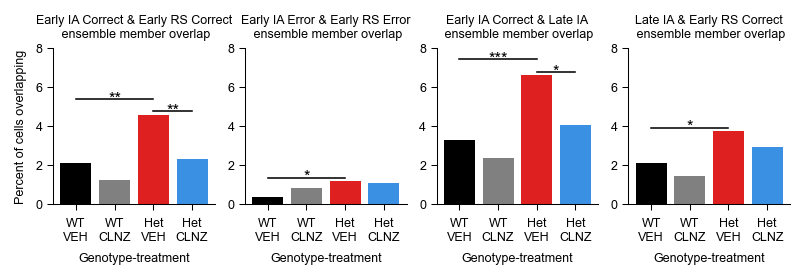

In [42]:
#decide genoplot to amke 
geno_to_plot = ["WT VEH", "WT CLNZ", "Het VEH", "Het CLNZ"]
compare_HET_v_CLNZ_in_WT_VEH= [("WT VEH", "WT CLNZ"), ("Het VEH", "Het CLNZ"), ("WT VEH", "Het VEH")]
sig_ensemble_overlap = [("WT VEH", "Het VEH"), ("Het VEH", "Het CLNZ")]
fig,ax_array = plt.subplots(1,len(all_ensemble_pairs), figsize = (5.25,1.75), layout = 'constrained')
posthoc_df_list = []
ylim_list = [8,8, 8, 8]
## iterate over all wt clnz comparisons
for e, ensemble_to_plot in enumerate(all_ensemble_pairs):
    ax= ax_array.flat[e]
    comparison_mask = (overlap_dff.set_1_name == ensemble_to_plot[0]).values & (overlap_dff.set_2_name == ensemble_to_plot[1]).values
    ensemble_df = overlap_dff.loc[comparison_mask,:]
    plot_df = ensemble_df.loc[ensemble_df.geno_day.isin(geno_to_plot),:]
    plot_params = dict( data =plot_df, x = 'geno_day',y = 'percent_total_overlap',dodge = False,  hue = 'geno_day', hue_order = geno_to_plot, order = geno_to_plot, palette = color_list_WT_CLNZ)
    
    sc= sns.barplot(ax=ax,**plot_params)
    ax_title= f"{' & '.join([x.replace('_', ' ') for x in ensemble_to_plot])}\n ensemble member overlap"
    ylabel = {True:  "Percent of cells overlapping", False: None}
    set_labels(ax, label_dict = dict(title = ax_title, xlabel= "Genotype-treatment", ylabel = ylabel[e ==0], ylim = [0,ylim_list[e]],  legend_false = True))
    
    ##posthoc annot  
    posthoc_df = main_run_posthoc_tests_and_get_hue_loc_df(ax, plot_params, sc, compare_HET_v_CLNZ_in_WT_VEH,test_name = 'none',ax_var_is_hue = True,
                                                               detect_error_bar=False,plot_type= 'barplot') # plot_sig_bars_w_comp_df_tight(plot_ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:])
    chi_res = [chi2_contingency(plot_df.set_index('geno_day').loc[group,['total_overlap', 'n_total']]) for group in compare_HET_v_CLNZ_in_WT_VEH]
    ## combine into new format
    real_pvalues  = make_premade_comparison_pvalue_df(compare_HET_v_CLNZ_in_WT_VEH, [x.pvalue for x in chi_res])
    posthoc_df= update_posthoc_pvalues(posthoc_df, comparison_pvalues = real_pvalues)    ## make table with precomputed comparison p-value for overwrite  
    posthoc_df.loc[:,'category_compared_within'] = "_x_".join(ensemble_to_plot)
    posthoc_df.stat_result  = [[x.statistic, x.pvalue] for x in chi_res]
    posthoc_df.loc[:,'test_name'] = "chi_squared"
    posthoc_df_list.append(posthoc_df)
    plot_sig_bars_w_comp_df_tight(ax,  posthoc_df.loc[posthoc_df['pvalue'] < 0.05,:],tight_offset = 0.02,offset_constant=0.015)
    ax.set_xticklabels([x.get_text().replace(" ", "\n") for x in ax.get_xticklabels()])
## save it
posthoc_df = pd.concat(posthoc_df_list)
fig_name = f"DFF revision Supplement- VEH v CLNZ for Het & WT- ensemble proportion overlap"
save_plot_record_as_csv_txt(posthoc_df,folder_pref:="2_s",fig_name,  csv_folder_most_recent, None, csv_suffix="ensemble chisquared",txt_suffix="ensemble chi test")
save_fig_in_main_fig_dir(fig, fig_name= fig_name, folder_key='r_1', filetypes_to_save = ['png'],bbox_inches="tight",pad_inches=0)